# Entrenamiento de Random Forest con IoT-23

IoT-23, desarrollado por el grupo Stratosphere IPS de la Czech Technical University (CTU) en 2020, es uno de los conjuntos de datos más representativos para el estudio de amenazas dirigidas específicamente a dispositivos IoT.

En este notebook seguimos la misma línea del experimento de `RF_train.ipynb`, pero adaptándolo a IoT-23. Primero fusionamos los ficheros `datos_IOT_23_1_1_redux.csv` y `datos_IOT_23_3_1_redux.csv`, obteniendo un único dataset con `473 811` flujos benignos y `691 040` flujos maliciosos. A partir de ahí, preparamos los datos, entrenamos un modelo base y utilizamos Optuna para buscar configuraciones que maximicen `F1-macro` y minimicen la latencia de inferencia.

Para evitar fuga de información, la columna `detailed-label` se excluye del entrenamiento, ya que describe directamente el tipo de ataque y convertiría el problema en uno artificialmente sencillo.


In [1]:
import os
import time
import ipaddress
import joblib
import numpy as np
import polars as pl
import psutil
import optuna
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.model_selection import StratifiedKFold, train_test_split


/mnt/AI-DATA/placivm_tfg/PLACI_TFG/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# # LO COMENTO PORQUE YA LO HICE EN OTRO SCRIPT, PERO LO DEJO AQUÍ POR SI QUIERO VOLVER A HACERLO

# # ==========================================
# # 1. FUSIÓN DE LOS DOS BLOQUES DE IOT-23
# # ==========================================
# path_iot_1 = "../../DATASETS/dataSets_Reducidos/iot-23/datos_IOT_23_1_1_redux.csv"
# path_iot_2 = "../../DATASETS/dataSets_Reducidos/iot-23/datos_IOT_23_3_1_redux.csv"
# merged_path = "../../DATASETS/dataSets_Reducidos/iot-23/datos_IOT_23_1_1_3_1_merge_redux.csv"


# def load_iot_csv(path):
#     return pl.read_csv(path, null_values="-", infer_schema_length=10000)


# df_iot_1 = load_iot_csv(path_iot_1)
# df_iot_2 = load_iot_csv(path_iot_2)

# for extra_col in ["", "Unnamed: 0"]:
#     if extra_col in df_iot_1.columns:
#         df_iot_1 = df_iot_1.drop(extra_col)
#     if extra_col in df_iot_2.columns:
#         df_iot_2 = df_iot_2.drop(extra_col)

# df_merged = pl.concat([df_iot_1, df_iot_2], how="vertical_relaxed")
# df_merged.write_csv(merged_path)

# conteo_etiquetas = (
#     df_merged
#     .group_by("label")
#     .len()
#     .rename({"len": "total"})
#     .sort("label")
# )

# benignos = int(conteo_etiquetas.filter(pl.col("label") == "Benign")["total"][0])
# maliciosos = int(conteo_etiquetas.filter(pl.col("label") == "Malicious")["total"][0])

# print(f"Dataset fusionado guardado en: {merged_path}")
# print(f"Forma del dataset fusionado: {df_merged.shape}")
# print(f"Benignos:   {benignos:,}")
# print(f"Maliciosos: {maliciosos:,}")
# display(conteo_etiquetas)


Dataset fusionado guardado en: ../../DATASETS/dataSets_Reducidos/iot-23/datos_IOT_23_1_1_3_1_merge_redux.csv
Forma del dataset fusionado: (1164851, 13)
Benignos:   473,811
Maliciosos: 691,040


label,total
str,u32
"""Benign""",473811
"""Malicious""",691040


In [ ]:
# # Hacemos que la clase a predecir del dataset sea binaria

# df_bin = df_merged.with_columns(
#     pl.when(pl.col("label").str.strip_chars().str.to_lowercase() == "benign")
#     .then(0)
#     .otherwise(1)
#     .alias("label")
# ).drop("detailed-label")

# output_path = "../../DATASETS/dataSets_Reducidos/iot-23/datos_IOT_23_1_1_3_1_merge_redux_bin.csv"
# df_bin.write_csv(output_path)

# print(f"Dataset binario guardado en: {output_path}")
# print(f"Distribución de clases:")
# print(df_bin.group_by("label").len().sort("label"))

# print(df_bin.dtypes)


Dataset binario guardado en: ../../DATASETS/dataSets_Reducidos/iot-23/datos_IOT_23_1_1_3_1_merge_redux_bin.csv
Distribución de clases:
shape: (2, 2)
┌───────┬────────┐
│ label ┆ len    │
│ ---   ┆ ---    │
│ i32   ┆ u32    │
╞═══════╪════════╡
│ 0     ┆ 473811 │
│ 1     ┆ 691040 │
└───────┴────────┘
[String, Int64, String, Int64, String, Float64, Int64, Int64, Int64, Int64, String, Int32]


In [ ]:
# # ==========================================
# # 2. LIMPIEZA Y PREPARACIÓN DE VARIABLES
# # ==========================================
# TARGET_COL = "label"

# df_model = (
#     df_bin
#     .with_columns([
#         # Mantenemos solo las variables de comportamiento (puertos, bytes, paquetes, estado)
#         pl.col("id.orig_p").cast(pl.Int32, strict=False).fill_null(-1).alias("id.orig_p"),
#         pl.col("id.resp_p").cast(pl.Int32, strict=False).fill_null(-1).alias("id.resp_p"),
#         pl.col("duration").cast(pl.Float64, strict=False).fill_null(-1.0).alias("duration"),
#         pl.col("orig_bytes").cast(pl.Float64, strict=False).fill_null(-1.0).alias("orig_bytes"),
#         pl.col("resp_bytes").cast(pl.Float64, strict=False).fill_null(-1.0).alias("resp_bytes"),
#         pl.col("orig_pkts").cast(pl.Int32, strict=False).fill_null(-1).alias("orig_pkts"),
#         pl.col("resp_pkts").cast(pl.Int32, strict=False).fill_null(-1).alias("resp_pkts"),
#         pl.col("proto").cast(pl.Utf8).fill_null("unknown").alias("proto"),
#         pl.col("conn_state").cast(pl.Utf8).fill_null("unknown").alias("conn_state"),
#     ])
#     # Eliminamos radicalmente las IPs de origen y destino para evitar Data Leakage
#     .drop(["id.orig_h", "id.resp_h"])
#     .drop_nulls()
# )

# filas_eliminadas = df_bin.shape[0] - df_model.shape[0]

# # Codificación One-Hot para las categóricas
# categorical_features = [col for col in ["proto", "conn_state"] if col in df_model.columns]
# df_encoded = df_model.to_dummies(columns=categorical_features)

# # Guardamos el dataset preparado 
# prepared_path = "../../DATASETS/dataSets_Reducidos/iot-23/datos_IOT_23_preparado.csv"
# df_encoded.write_csv(prepared_path)

# print(df_encoded.shape)

# # Separación de características (X) y variable objetivo (y)
# feature_columns = [col for col in df_encoded.columns if col != TARGET_COL]
# X = df_encoded.select(feature_columns)
# y_np = df_encoded[TARGET_COL].to_numpy().astype(np.int8)
# X_np = X.to_numpy()

# # Resumen de validación
# print(f"Número de muestras tras limpieza: {df_model.height:,}")
# print(f"Filas eliminadas por nulos residuales: {filas_eliminadas:,}")
# print(f"Número de variables finales: {X.width}")
# print(f"Variables categóricas: {categorical_features}")
# print(f"Clases en y: {np.unique(y_np)}")

# display(X.head())

(1164851, 23)
Número de muestras tras limpieza: 1,164,851
Filas eliminadas por nulos residuales: 0
Número de variables finales: 22
Variables categóricas: ['proto', 'conn_state']
Clases en y: [0 1]


id.orig_p,id.resp_p,proto_icmp,proto_tcp,proto_udp,duration,orig_bytes,resp_bytes,orig_pkts,resp_pkts,conn_state_OTH,conn_state_REJ,conn_state_RSTO,conn_state_RSTOS0,conn_state_RSTR,conn_state_RSTRH,conn_state_S0,conn_state_S1,conn_state_S2,conn_state_SF,conn_state_SH,conn_state_SHR
i32,i32,u8,u8,u8,f64,f64,f64,i32,i32,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8
51524,23,0,1,0,2.999051,0.0,0.0,3,0,0,0,0,0,0,0,1,0,0,0,0,0
56305,23,0,1,0,-1.0,-1.0,-1.0,1,0,0,0,0,0,0,0,1,0,0,0,0,0
41101,23,0,1,0,-1.0,-1.0,-1.0,1,0,0,0,0,0,0,0,1,0,0,0,0,0
60905,23,0,1,0,2.998796,0.0,0.0,3,0,0,0,0,0,0,0,1,0,0,0,0,0
44301,23,0,1,0,-1.0,-1.0,-1.0,1,0,0,0,0,0,0,0,1,0,0,0,0,0


In [2]:
# ==========================================
# 2. PREPARACION DATASET
# ==========================================

TARGET_COL = "label"

df_encoded = pl.read_csv("../../DATASETS/dataSets_Reducidos/iot-23/datos_IOT_23_preparado.csv")

# Separación de características (X) y variable objetivo (y)
feature_columns = [col for col in df_encoded.columns if col != TARGET_COL]
X = df_encoded.select(feature_columns)
y_np = df_encoded[TARGET_COL].to_numpy().astype(np.int8)
X_np = X.to_numpy()

display(X.head())

indices = np.arange(X_np.shape[0])

train_full_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=y_np,
)

train_idx, val_idx = train_test_split(
    train_full_idx,
    test_size=0.2,
    random_state=42,
    stratify=y_np[train_full_idx],
)

X_full_train_np = X_np[train_full_idx]
X_test_np = X_np[test_idx]
y_full_train = y_np[train_full_idx]
y_test_np = y_np[test_idx]

X_train_np = X_np[train_idx]
X_val_np = X_np[val_idx]
y_train_np = y_np[train_idx]
y_val_np = y_np[val_idx]

print(f"Entrenamiento: {len(X_train_np):,} muestras")
print(f"Validación:    {len(X_val_np):,} muestras")
print(f"Test:          {len(X_test_np):,} muestras")
print(f"Clases en test: {np.unique(y_test_np)}")
print(f"Total muestras: {len(X_np):,}")

id.orig_p,id.resp_p,proto_icmp,proto_tcp,proto_udp,duration,orig_bytes,resp_bytes,orig_pkts,resp_pkts,conn_state_OTH,conn_state_REJ,conn_state_RSTO,conn_state_RSTOS0,conn_state_RSTR,conn_state_RSTRH,conn_state_S0,conn_state_S1,conn_state_S2,conn_state_SF,conn_state_SH,conn_state_SHR
i64,i64,i64,i64,i64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
51524,23,0,1,0,2.999051,0.0,0.0,3,0,0,0,0,0,0,0,1,0,0,0,0,0
56305,23,0,1,0,-1.0,-1.0,-1.0,1,0,0,0,0,0,0,0,1,0,0,0,0,0
41101,23,0,1,0,-1.0,-1.0,-1.0,1,0,0,0,0,0,0,0,1,0,0,0,0,0
60905,23,0,1,0,2.998796,0.0,0.0,3,0,0,0,0,0,0,0,1,0,0,0,0,0
44301,23,0,1,0,-1.0,-1.0,-1.0,1,0,0,0,0,0,0,0,1,0,0,0,0,0


Entrenamiento: 745,504 muestras
Validación:    186,376 muestras
Test:          232,971 muestras
Clases en test: [0 1]
Total muestras: 1,164,851


In [3]:
def objective(trial):
    # 1. Sugerir hiperparámetros
    n_estimators = trial.suggest_int("n_estimators", 50, 600, step=50)
    max_depth = trial.suggest_int("max_depth", 2, 30)
    
    # 2. Configurar el Validador Cruzado (3 Folds Estratificados)
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    
    f1_scores = []
    latencies = []

    # 3. Bucle de Cross-Validation
    # ATENCIÓN: Usamos los nombres exactos de los arrays generados en el split anterior
    for train_idx, val_idx in skf.split(X_full_train_np, y_full_train):
        # Dividir datos del fold
        X_train_cv, X_val_cv = X_full_train_np[train_idx], X_full_train_np[val_idx]
        y_train_cv, y_val_cv = y_full_train[train_idx], y_full_train[val_idx]

        # Configurar modelo
        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            n_jobs=-1, 
            random_state=42,
            class_weight="balanced" # Al ser binario y estar bien balanceado, 'balanced' es suficiente
        )

        # Entrenamiento del fold
        model.fit(X_train_cv, y_train_cv)

        # Predicción y métrica de eficacia (F1)
        y_pred = model.predict(X_val_cv)
        
        # CAMBIO CRÍTICO: Al ser clasificación binaria, usamos average='binary' 
        # Esto evalúa qué tan bien detecta los ataques (clase 1)
        f1_scores.append(f1_score(y_val_cv, y_pred, average='binary'))

        # Medición de eficiencia (Latencia) en este fold
        subset = min(20000, len(X_val_cv)) 
        X_lat = X_val_cv[:subset]

        # Warm-up rápido para estabilizar la inferencia
        _ = model.predict(X_lat[:min(500, len(X_lat))])

        rep_lat = []
        for _ in range(3): 
            t0 = time.perf_counter()
            _ = model.predict(X_lat)
            t1 = time.perf_counter()
            rep_lat.append((t1 - t0) / len(X_lat) * 1000)

        latencies.append(float(np.mean(rep_lat)))

    # 4. Promediar resultados de los 3 folds
    avg_f1 = np.mean(f1_scores)
    avg_lat = np.mean(latencies)
    std_f1 = np.std(f1_scores) 

    # Guardamos atributos extra para el análisis posterior
    trial.set_user_attr("f1_std", std_f1)

    return avg_f1, avg_lat

# --- EJECUCIÓN ---

study = optuna.create_study(
    directions=["maximize", "minimize"],
    study_name="iot23_rf_optimization_cv"
)

print("🚀 Iniciando barrido multiobjetivo con 3-Fold Cross-Validation para IoT-23...")
print("Nota: Cada trial ahora entrena 3 modelos. Evaluando F1 Binario (Benigno vs Malicioso).")

# Puedes reducir n_trials si ves que tarda demasiado por el tamaño del dataset
study.optimize(objective, n_trials=50)

# ==========================================
# EXTRACCIÓN DE DATOS A POLARS
# ==========================================

trials_data = []
for t in study.trials:
    if t.state == optuna.trial.TrialState.COMPLETE:
        trials_data.append({
            "n_estimators": t.params["n_estimators"],
            "max_depth": t.params["max_depth"],
            "f1_binary": t.values[0], # Actualizado el nombre de la columna
            "f1_std": t.user_attrs["f1_std"],
            "latency_ms": t.values[1],
            "is_pareto": t in study.best_trials 
        })

df_results = pl.DataFrame(trials_data)
df_results.write_csv("rf_iot23_trials_results_cv.csv")

print("\n✅ Resultados robustos guardados en 'rf_iot23_trials_results_cv.csv'")
print(df_results.sort("f1_binary", descending=True).head())

[I 2026-04-20 18:56:52,390] A new study created in memory with name: iot23_rf_optimization_cv


🚀 Iniciando barrido multiobjetivo con 3-Fold Cross-Validation para IoT-23...
Nota: Cada trial ahora entrena 3 modelos. Evaluando F1 Binario (Benigno vs Malicioso).


[I 2026-04-20 18:57:08,240] Trial 0 finished with values: [0.9998779158002084, 0.004444797222276975] and parameters: {'n_estimators': 300, 'max_depth': 28}.
[I 2026-04-20 18:57:15,643] Trial 1 finished with values: [0.9952570178291863, 0.0028440430777562954] and parameters: {'n_estimators': 150, 'max_depth': 8}.
[I 2026-04-20 18:57:37,579] Trial 2 finished with values: [0.9952803171795491, 0.007415246199990281] and parameters: {'n_estimators': 550, 'max_depth': 9}.
[I 2026-04-20 18:57:58,878] Trial 3 finished with values: [0.9983909005900761, 0.0073830082166548685] and parameters: {'n_estimators': 500, 'max_depth': 16}.
[I 2026-04-20 18:58:04,042] Trial 4 finished with values: [0.9931322621143847, 0.0022962987055305142] and parameters: {'n_estimators': 100, 'max_depth': 6}.
[I 2026-04-20 18:58:21,272] Trial 5 finished with values: [0.9914567922819454, 0.0059609070555274625] and parameters: {'n_estimators': 450, 'max_depth': 5}.
[I 2026-04-20 18:58:39,209] Trial 6 finished with values: 


✅ Resultados robustos guardados en 'rf_iot23_trials_results_cv.csv'
shape: (5, 6)
┌──────────────┬───────────┬───────────┬──────────┬────────────┬───────────┐
│ n_estimators ┆ max_depth ┆ f1_binary ┆ f1_std   ┆ latency_ms ┆ is_pareto │
│ ---          ┆ ---       ┆ ---       ┆ ---      ┆ ---        ┆ ---       │
│ i64          ┆ i64       ┆ f64       ┆ f64      ┆ f64        ┆ bool      │
╞══════════════╪═══════════╪═══════════╪══════════╪════════════╪═══════════╡
│ 100          ┆ 27        ┆ 0.999885  ┆ 0.000011 ┆ 0.002308   ┆ true      │
│ 100          ┆ 28        ┆ 0.999883  ┆ 0.000015 ┆ 0.002282   ┆ true      │
│ 200          ┆ 28        ┆ 0.999881  ┆ 0.000021 ┆ 0.003399   ┆ false     │
│ 150          ┆ 28        ┆ 0.99988   ┆ 0.00002  ┆ 0.002841   ┆ false     │
│ 450          ┆ 28        ┆ 0.999879  ┆ 0.000019 ┆ 0.006463   ┆ false     │
└──────────────┴───────────┴───────────┴──────────┴────────────┴───────────┘


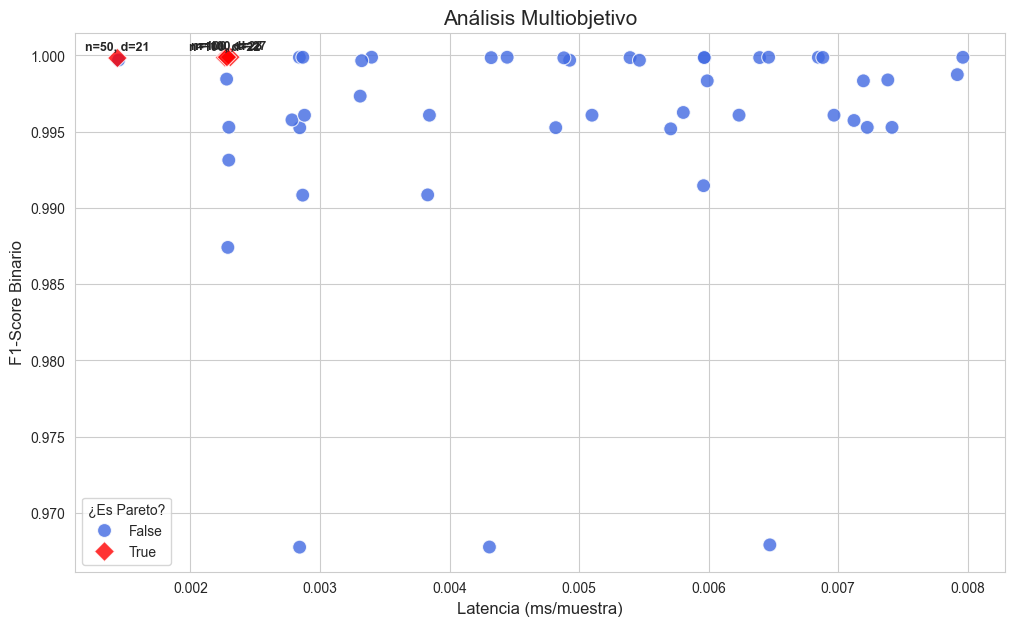

In [6]:
# 1. Cargamos los resultados
df = pl.read_csv("rf_iot23_trials_results_cv.csv")

# 2. Configuramos el estilo
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# 3. Graficamos extrayendo columnas directamente como NumPy
# Al no usar 'data=df', Seaborn acepta arrays de NumPy sin quejarse
sns.scatterplot(
    x=df["latency_ms"].to_numpy(), 
    y=df["f1_binary"].to_numpy(), 
    hue=df["is_pareto"].to_numpy(), # Aquí pasamos la serie de booleanos
    palette={True: "red", False: "royalblue"},
    style=df["is_pareto"].to_numpy(),
    markers={True: "D", False: "o"},
    s=100,
    alpha=0.8
)

# 4. Anotaciones de los puntos Pareto (esto ya lo hacíamos con Polars)
pareto_points = df.filter(pl.col("is_pareto") == True)

for row in pareto_points.iter_rows(named=True):
    plt.text(
        row["latency_ms"], 
        row["f1_binary"] + 0.0005, 
        f"n={int(row['n_estimators'])}, d={int(row['max_depth'])}",
        fontsize=9, fontweight='bold', ha='center'
    )

# 5. Estética
plt.title("Análisis Multiobjetivo", fontsize=15)
plt.xlabel("Latencia (ms/muestra)", fontsize=12)
plt.ylabel("F1-Score Binario", fontsize=12)
plt.legend(title="¿Es Pareto?")

plt.show()

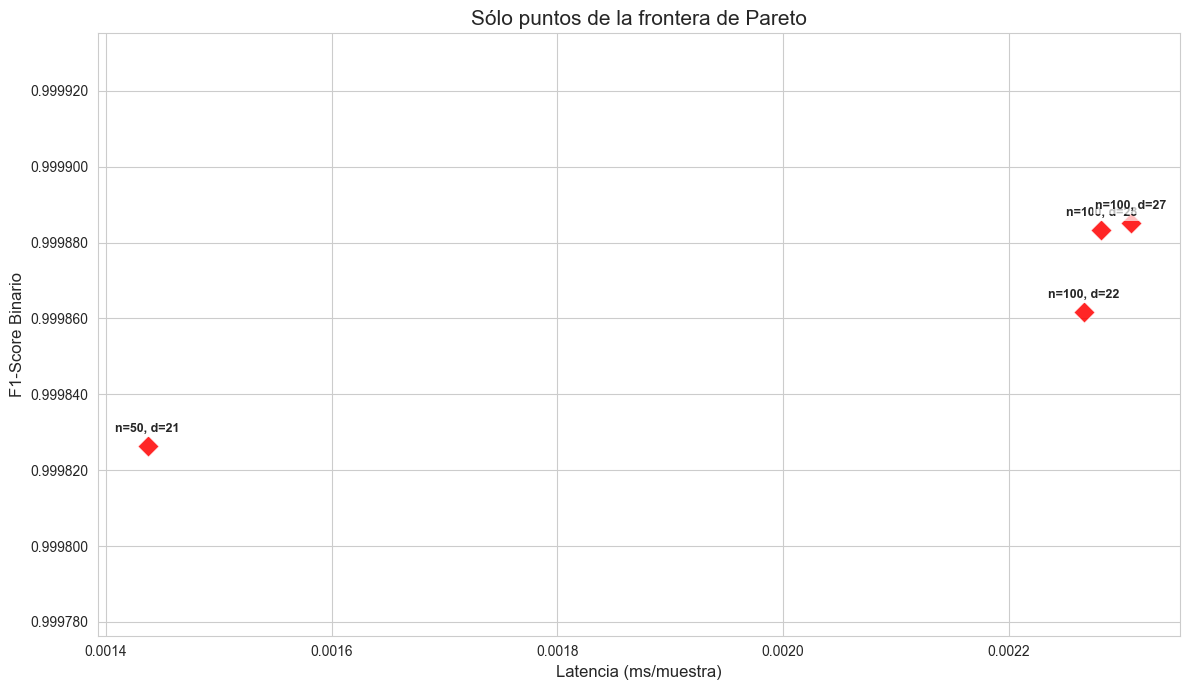

n_estimators,max_depth,f1_binary,f1_std,latency_ms,is_pareto
i64,i64,f64,f64,f64,bool
50,21,0.999826,0.000039,0.001437,true
100,22,0.999862,0.000018,0.002267,true
100,28,0.999883,0.000015,0.002282,true
100,27,0.999885,0.000011,0.002308,true


In [12]:
# representamos únicamente los puntos que forman la frontera de Pareto

from matplotlib.ticker import FormatStrFormatter

# 1. cargamos los resultados y filtramos
df = pl.read_csv("rf_iot23_trials_results_cv.csv")
pareto = (
    df
    .filter(pl.col("is_pareto") == True)
    .sort("latency_ms")
)

# 2. estilo
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
ax = plt.gca()

# 3. dibujamos sólo los puntos de Pareto
sns.scatterplot(
    x=pareto["latency_ms"].to_numpy(),
    y=pareto["f1_binary"].to_numpy(),
    color="red",
    marker="D",
    s=120,
    alpha=0.85,
    ax=ax
)

# Evitamos el formato raro del eje Y cuando los F1 están muy cerca de 1.0
ax.ticklabel_format(style='plain', axis='y', useOffset=False)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.6f'))

# Añadimos un pequeño margen vertical para que respiren los puntos
y_vals = pareto["f1_binary"].to_numpy()
if len(y_vals) > 0:
    y_min = float(y_vals.min())
    y_max = float(y_vals.max())
    margin = max((y_max - y_min) * 0.2, 0.00005)
    ax.set_ylim(y_min - margin, y_max + margin)

# 4. anotamos cada punto pegado a su marca roja
for row in pareto.iter_rows(named=True):
    ax.annotate(
        f"n={int(row['n_estimators'])}, d={int(row['max_depth'])}",
        xy=(row["latency_ms"], row["f1_binary"]),
        xytext=(0, 8),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1.5)
    )

# 5. etiquetas
plt.title("Sólo puntos de la frontera de Pareto", fontsize=15)
plt.xlabel("Latencia (ms/muestra)", fontsize=12)
plt.ylabel("F1-Score Binario", fontsize=12)
plt.tight_layout()
plt.show()

# Mostramos los puntos de Pareto
display(pareto)

In [13]:
# Definimos tus 3 configuraciones finalistas
candidatos = [
    {"n": 50,  "d": 21, "nombre": "Candidato 1"},
    {"n": 100,  "d": 22, "nombre": "Candidato 2"},
    {"n": 100, "d": 28, "nombre": "Candidato 3"},
    {"n": 100, "d": 27, "nombre": "Candidato 4"}
]

resultados_finales = []

print("--- EVALUACIÓN FINAL SOBRE EL SET DE TEST ---\n")

for c in candidatos:
    print(f"Probando: {c['nombre']} (n={c['n']}, d={c['d']})...")
    
    # 1. Crear y Entrenar (usamos X_full_train que es la suma de train + val)
    model = RandomForestClassifier(
        n_estimators=c['n'],
        max_depth=c['d'],
        n_jobs=-1,
        random_state=42,
        class_weight="balanced_subsample"
    )
    model.fit(X_full_train_np, y_full_train)
    
    # 2. Medir Inferencia en TEST con el mismo protocolo de latencia que en Optuna
    subset = min(20000, len(X_test_np))
    X_lat = X_test_np[:subset]

    # Warm-up rápido
    _ = model.predict(X_lat[:min(500, len(X_lat))])

    rep_lat = []
    for _ in range(3):
        t0 = time.perf_counter()
        _ = model.predict(X_lat)
        t1 = time.perf_counter()
        rep_lat.append((t1 - t0) / len(X_lat) * 1000)

    y_pred = model.predict(X_test_np)
    
    # 3. Calcular métricas
    latencia = float(np.mean(rep_lat))
    f1_test = f1_score(y_test_np, y_pred, average='binary')
    acc_test = accuracy_score(y_test_np, y_pred)
    
    resultados_finales.append({
        "Perfil": c['nombre'],
        "n_estimators": c['n'],
        "max_depth": c['d'],
        "F1_Binary_Test": f1_test,
        "Accuracy_Test": acc_test,
        "Latencia_ms": latencia
    })

# Convertimos a Polars para mostrar la tabla final
df_final = pl.DataFrame(resultados_finales)
print("\n" + "="*60)
print("              TABLA COMPARATIVA FINAL")
print("="*60)
print(df_final)

--- EVALUACIÓN FINAL SOBRE EL SET DE TEST ---

Probando: Candidato 1 (n=50, d=21)...
Probando: Candidato 2 (n=100, d=22)...
Probando: Candidato 3 (n=100, d=28)...
Probando: Candidato 4 (n=100, d=27)...

              TABLA COMPARATIVA FINAL
shape: (4, 6)
┌─────────────┬──────────────┬───────────┬────────────────┬───────────────┬─────────────┐
│ Perfil      ┆ n_estimators ┆ max_depth ┆ F1_Binary_Test ┆ Accuracy_Test ┆ Latencia_ms │
│ ---         ┆ ---          ┆ ---       ┆ ---            ┆ ---           ┆ ---         │
│ str         ┆ i64          ┆ i64       ┆ f64            ┆ f64           ┆ f64         │
╞═════════════╪══════════════╪═══════════╪════════════════╪═══════════════╪═════════════╡
│ Candidato 1 ┆ 50           ┆ 21        ┆ 0.999675       ┆ 0.999614      ┆ 0.001496    │
│ Candidato 2 ┆ 100          ┆ 22        ┆ 0.999855       ┆ 0.999828      ┆ 0.002252    │
│ Candidato 3 ┆ 100          ┆ 28        ┆ 0.999906       ┆ 0.999888      ┆ 0.002363    │
│ Candidato 4 ┆ 100      